# Import libs

In [1]:
from regime_identification.Features.features import get_log
from regime_identification.Splitting.split import find_split, add_f
from regime_identification.Features.regimes import get_corrM_roll, get_long_corrM, expanding_norm, get_pca, scree_pca, plot_clusters

import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm # Loading bars

# Data retrieval

In [2]:
# Update ETF data
# %run update_data.py

In [3]:
# Importing unprocessed data
from data_script import config, exm, etfs

Loading data...
ETFs


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 36.16it/s]


Extramarket

Done!


# Data processing

In [4]:
# Close-Close log returns for ETF data
for i in tqdm(etfs):
    etfs[i]["Ticker"] = i # Used later for ID
    etfs[i]["logret"] = get_log(etfs[i]["Close"])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 759.67it/s]


In [5]:
# Extramarket data
'''
Extramarket data is tricky, as some features are to be standardized,
while others should be the logarithmic returns (adjusted for inflation or otherwise)
Additionally, standardization should be done in expanding-window manner for test data.
'''

# Standardize
stdize = ["BLP", "FF", "pe_ratio"] 

# Logret & adjust for inflation
commodities = ["electricity_kwh", "gasoline_gallon", 
               "household-gas_therm", "housing", "gold"]

# Unadjusted logret
fx = ["fx_JPUS", "fx_USEU", "fx_USUK",
      "VIX", # Not really an FX, but should be processed the same way
     ]

exm_p = exm.copy() # exm_p = ex(tra)m(arket) processed data

In [6]:
# FX processing
for i in fx:
    exm_p[i] = get_log(exm[i].dropna(how = "any"))

In [7]:
# Commodities processing
log_inflation = get_log(exm["inflation_cpi"].dropna(how = "any").astype(float))
exm_p["log_inflation"] = log_inflation

for i in commodities:
    exm_p[i] = get_log(exm[i].dropna(how = "any")) - log_inflation

Expanding-window standardization for `stdize` happens later (together with all other features)

## Correlation

The recent degree of correlation between features can be indicative of a regime. Thus, we calculate a rolling correlation matrix between all features to later be fed into the model.

In [8]:
'''
window = config["CORR_WINDOW"]

corrM = get_corrM_roll(exm_p, window)
long_corrM = get_long_corrM(corrM)
'''

'\nwindow = config["CORR_WINDOW"]\n\ncorrM = get_corrM_roll(exm_p, window)\nlong_corrM = get_long_corrM(corrM)\n'

## Splitting into test & training

To simulate a live environment, we have to split the data into training (seen/future) and test (unseen/future). Training data will be processed as a single entity while test data processing uses an expanding window to ensure only past data is used.

The first of january 2019 is chosen as the split date to allow a variety of regimes to be identified in the test data (most notably, the 2020 COVID-19 recession)

In [9]:
split_date = pd.to_datetime(date(2019, 1, 1))

## Forward-filling

Forward filling is limited to 1 calendar month at most.

In [10]:
exm_p.shape

(21901, 18)

In [11]:
# Forward-fill to max 1 month
def ffill_month(df, months = 1):
    df = df.sort_index()

    # empty index with every missing DAILY date
    full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")

    result = df.reindex(full_index).ffill()

    # Most recent original observation for each date
    last_obs = pd.Series(
        df.index,
        index=df.index
    ).reindex(full_index).ffill()

    # Only keep if within one calendar month
    valid = full_index <= last_obs + pd.DateOffset(months=months)

    result = result.where(valid)

    return result

exm_p = ffill_month(exm_p)

In [12]:
exm_p.shape

(280760, 18)

## Standardization

Unsupervised learning (PCA & clustering) algorithms generally require standardized data.

The training data is standardized by the entirety of the available data. The test data is standardized in an expanding fashion (which includes training data).

In [13]:
exm_p_norm = expanding_norm(exm_p, norm_start = split_date)

In [14]:
exm_p_norm.describe()

,electricity_kwh,gasoline_gallon,household-gas_therm,housing,inflation_cpi,BLP,FF,pe_ratio,treasury_yield_3mo,treasury_yield_10y,treasury_yield_curve,GDP,fx_JPUS,fx_USEU,fx_USUK,gold,VIX,log_inflation
count,17452.000000,17452.000000,17452.000000,17452.000000,17482.000000,11212.000000,11212.000000,56867.000000,16447.000000,16447.000000,16447.000000,23629.000000,20339.000000,10112.000000,20339.000000,17452.000000,13401.000000,17452.000000
mean,0.010558,0.007460,0.013038,0.017427,0.320447,0.061300,0.050325,0.058265,-0.052914,-0.139384,0.095615,-0.119790,0.002669,0.002530,0.004164,0.014256,-0.005182,0.010967
std,0.938319,1.027419,1.006306,1.000332,1.176049,0.986466,0.980463,1.013352,0.955715,0.980526,1.079544,1.008299,0.989533,0.933405,0.990361,0.950339,1.040734,0.993590
min,-3.294908,-7.496381,-4.685770,-3.950987,-1.915361,-1.020586,-1.060336,-1.240932,-1.239794,-1.678783,-1.704487,-1.915061,-14.737607,-4.785343,-13.628112,-4.344356,-6.472573,-6.545991
25%,-0.354361,-0.422160,-0.435434,-0.546080,-0.638306,-0.992807,-0.982849,-0.491947,-0.950740,-0.932270,-0.971357,-0.782072,-0.436025,-0.513506,-0.479974,-0.456904,-0.593533,-0.479357
50%,-0.058271,-0.045522,-0.033775,-0.056320,0.287995,-0.201294,-0.247062,-0.077587,-0.015379,-0.346083,0.421904,-0.270973,0.000858,-0.005835,0.024853,-0.054150,-0.076626,-0.081132
75%,0.361616,0.472255,0.442920,0.503497,1.359017,1.179971,1.114965,0.341270,0.519134,0.422512,0.909299,0.466492,0.494020,0.509823,0.511320,0.477089,0.496146,0.400673
max,4.001909,4.276926,5.818239,7.320843,2.249202,1.868959,2.433714,12.864508,3.990864,3.252574,2.752432,3.357216,9.701009,7.381019,7.693366,8.289380,11.829523,3.638383


In [15]:
# drop inflation CPI because not informative
exm_p_norm = exm_p_norm.drop("inflation_cpi", axis = 1)

## PCA & residualization

To ensure that high degrees of correlation between features do not cause over-emphasization of underlying macro-economic events, PCA is used to approximate & isolate these grander events. Residualization is then applied to isolate the effects of individual features. 

In [16]:
# Can't have NAs in PCA, so drop them
exm_p_norm = exm_p_norm.dropna(how = "any")
# Can only fit PCA on training data
training = exm_p_norm[exm_p_norm.index < split_date]

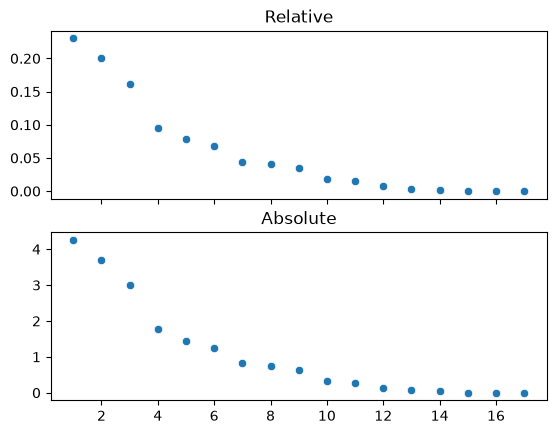

In [17]:
# Initial PCA without limits
pca, training_pcs = get_pca(training)
scree_pca(pca)

It seems our elbow is at around 4 PCs. Keep 5 to be sure.

In [18]:
# PCA restricted to most explanatory PCs
pca, training_pcs = get_pca(training, n_components = 5)

pcs = pd.DataFrame(pca.transform(exm_p_norm), index = exm_p_norm.index)
pcs.columns = [f"PC{i}" for i in pcs.columns] # Rename for clarity

In [19]:
# Residualize features
residuals = exm_p_norm - pca.inverse_transform(pcs)

In [20]:
residuals.describe()

,electricity_kwh,gasoline_gallon,household-gas_therm,housing,BLP,FF,pe_ratio,treasury_yield_3mo,treasury_yield_10y,treasury_yield_curve,GDP,fx_JPUS,fx_USEU,fx_USUK,gold,VIX,log_inflation
count,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000
mean,0.003195,-0.020812,-0.011736,0.026757,-0.031034,-0.043351,0.011542,0.003187,-0.082954,0.115633,-0.093846,0.002946,-0.002532,0.003322,0.000785,-0.007314,0.066248
std,0.800772,0.409809,0.077456,0.364894,0.131734,0.135231,0.038354,0.075866,0.261999,0.348981,0.282610,0.827304,0.430493,0.523229,0.765739,1.076935,0.342997
min,-2.420099,-1.214403,-0.284739,-1.075793,-0.591142,-0.611342,-0.149393,-0.399224,-0.917550,-0.745732,-0.982704,-8.934191,-2.385753,-8.236868,-3.104291,-6.528634,-1.093643
25%,-0.346844,-0.307508,-0.057879,-0.247347,-0.107087,-0.118148,-0.016114,-0.028012,-0.250592,-0.114694,-0.273954,-0.404888,-0.247229,-0.256273,-0.494565,-0.619411,-0.129514
50%,-0.082825,-0.040305,-0.010979,0.000857,-0.013573,-0.014985,0.011633,0.012613,-0.093948,0.026589,-0.107017,0.005817,0.000246,0.015499,-0.054256,-0.095873,0.053317
75%,0.292242,0.235216,0.035549,0.277325,0.071328,0.057573,0.037738,0.049224,0.101461,0.230430,0.103479,0.415920,0.239045,0.272954,0.473010,0.498784,0.214637
max,2.849935,1.231859,0.336929,1.187516,0.422402,0.731071,0.162613,0.219409,0.535252,1.946299,0.571726,5.594055,2.233901,3.298087,3.470414,11.846892,1.348940


# Identify regime clusters

In [21]:
from sklearn.cluster import MiniBatchKMeans

# number of clusters
n_clusters = 4
# Combine PCs and residuals
full = pcs.join(residuals)
# Can only fit on training data
training = full[full.index < split_date]

km = MiniBatchKMeans(n_clusters = n_clusters)
km = km.fit(training)

clusters = pd.DataFrame(km.predict(full), index = full.index)

full["cluster"] = clusters

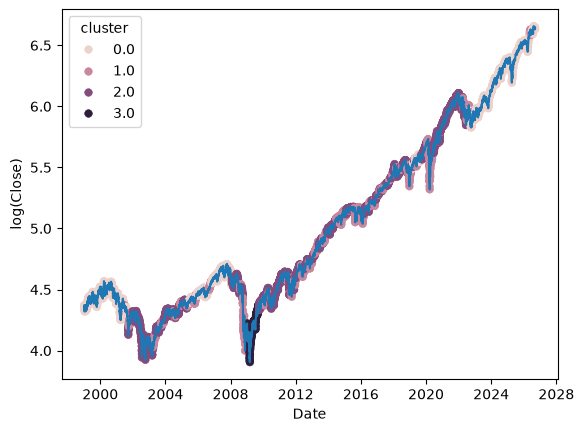

In [22]:
plot_clusters(clusters)

## Best and worst performers per phase

We can rate the per-regime performance of asset classes via the next-day-closing returns of a representative ETF. 

There are many metrics to rate stock performance by, such as raw returns or sharpe ratio. Here, stocks are **rated by sortino ratio**, where returns are penalized for their downside volatility only (as opposed to bidirectional volatility with sharpe ratio). This is done in the interest of minimizing risk for leveraged positions. 

Note that the worst performers (to be shorted) should also have the lowest upside volatility (hence the altered "inverse" sortino formula).

In [63]:
for ticker, df in etfs.items():
    df = df.join(full["cluster"])
    
    # Annualize logret for readability
    df["logret_annual"] = df["logret"] * 252
    
    # Next-day returns
    df["f_logret"] = df["logret"].shift(-1) 
    df["f_logret_annual"] = df["logret_annual"].shift(-1)

    df["set"] = None
    df.loc[df.index < split_date, "set"] = "training"
    df.loc[df.index > split_date, "set"] = "test"

    # Write
    etfs[ticker] = df

ValueError: columns overlap but no suffix specified: Index(['cluster'], dtype='str')

In [64]:
etfs["GLD"].columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Capital Gains', 'Ticker', 'logret', 'logret_annual', 'f_logret',
       'f_logret_annual', 'set', 'cluster'],
      dtype='str')

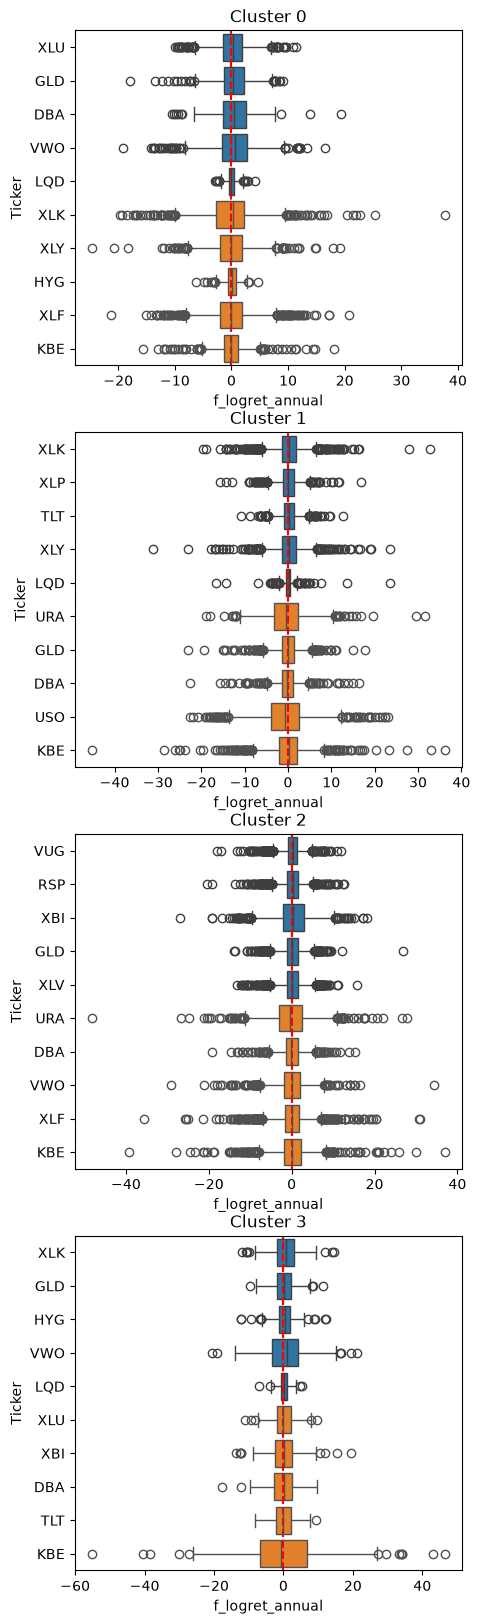

In [65]:
fig, ax = plt.subplots(n_clusters, 1, figsize = (5, 20))

df = pd.concat(etfs.values()) # values() to avoid redundant multiindex

# Don't show VIX, as it is not an asset class
df = df[df["Ticker"] != "^VIX"]

'''
axis = 0
for i in ["training", "test"]:
    sns.boxplot(data = df[df["set"] == i].reset_index(), x = 'f_1d_Close_logret', y = "Ticker", 
                hue = "cluster", # orient = "v",
                ax = ax[axis],
               ).set_title(i)
    ax[axis].set_xlim(-0.10, 0.10)
    ax[axis].axvline(x = 0, color = "red", linestyle = "--")
    axis += 1
    
'''

n_tickers = 5 # How many tickers to display for each side
axis = 0
best_tickers = {}
worst_tickers = {}
for i in range(n_clusters):
    # Again, only use training data to evaluate performance pre-testing
    best_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: np.sum(x) / np.std(x[x < 0])).nlargest(n_tickers, keep = "first").index 
    best_tickers_sortino = list(best_tickers_sortino)
    best_tickers[i] = best_tickers_sortino

    worst_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: -np.sum(x) / np.std(x[x > 0])).nlargest(n_tickers, keep = "first").index 
    worst_tickers_sortino = list(worst_tickers_sortino)
    worst_tickers[i] = worst_tickers_sortino

    for j in [best_tickers_sortino, worst_tickers_sortino]:
        sns.boxplot(data = df[(df["cluster"] == i) & (df["set"] == "training") & (df["Ticker"].isin(j))].reset_index(), x = 'f_logret_annual', y = "Ticker", 
                    # hue = "set", # orient = "v",
                    ax = ax[axis],
                   ).set_title(f"Cluster {i}")
        # ax[axis].set_xlim(-1, 1)
        ax[axis].axvline(x = 0, color = "red", linestyle = "--")

    
    axis += 1
        
plt.show()
plt.close()

# Statistical testing

Note that all of these tests are **only performed on training data!** We want to establish a "realistic" strategy based on 2019 data to backtest later.

alpha p < 0.10 is chosen as significant. This is high in relation to traditional p-values. The justification is that less-significant differences in return distributions may still provide economically relevant results. This is also the reason I will not be adjusting for the multiple comparisons problem of testing many asset classes.

In [131]:
alpha = 0.1

## Between regimes

### Distributions

As we cannot assume neither normal distributions nor heteroscedasticity, the use of a non-parametric test will give the most accurate results for comparing return distributions between and within asset classes and regimes. For this we use the **Kruskal-Wallis test**.

In [ ]:
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn as dunn

In [148]:
br_dfs = {} # Dict of between-regime cluster future returns
for ticker, df in etfs.items():
    df = df[df["set"] == "training"] # Use only training data!
    result = df.groupby("cluster")["f_logret"].apply(list).apply(pd.Series).T

    result.columns.name = None   

    br_dfs[ticker] = result

In [149]:
sig_br = {} # Significant tickers
for ticker, df in br_dfs.items():
    df_l = [list(df[c]) for c in df.columns] # Split needed for scipy API
    H_stat, p_stat = kruskal(*df_l, nan_policy = "omit")
    if p_stat < alpha:
        print(f"Ticker: {ticker}; H: {H_stat}; p: {p_stat}")
        sig_br[ticker] = df

Ticker: GLD; H: 12.746011495551283; p: 0.005219340476468753
Ticker: DBA; H: 9.926395238793248; p: 0.019202277088193453
Ticker: USO; H: 20.022325024084303; p: 0.0001679436828588057
Ticker: XLY; H: 6.3855736993956445; p: 0.09428608885922324
Ticker: VWO; H: 9.902867426847562; p: 0.01941010172284252


It seems **gold (GLD), agriculture (DBA), oil (USO), consumer luxury (XLY) and emerging markets (VWO)** have significantly (p < 0.10) altered behaviour depending on market regime. 

Lets check when they perform better or worse.

In [150]:
for ticker, df in sig_br.items():
    df_l = [list(df[c]) for c in df.columns] # Split needed for scipy API
    du = dunn(df_l, p_adjust = "bonferroni")
    print(f"Ticker: {ticker} \n{du[du < alpha]}\n")

Ticker: GLD 
          1         2   3   4
1       NaN  0.003008 NaN NaN
2  0.003008       NaN NaN NaN
3       NaN       NaN NaN NaN
4       NaN       NaN NaN NaN

Ticker: DBA 
          1         2   3   4
1       NaN  0.013601 NaN NaN
2  0.013601       NaN NaN NaN
3       NaN       NaN NaN NaN
4       NaN       NaN NaN NaN

Ticker: USO 
          1         2         3   4
1       NaN  0.028218       NaN NaN
2  0.028218       NaN  0.000118 NaN
3       NaN  0.000118       NaN NaN
4       NaN       NaN       NaN NaN

Ticker: XLY 
          1         2   3   4
1       NaN  0.088089 NaN NaN
2  0.088089       NaN NaN NaN
3       NaN       NaN NaN NaN
4       NaN       NaN NaN NaN

Ticker: VWO 
          1         2   3   4
1       NaN  0.059919 NaN NaN
2  0.059919       NaN NaN NaN
3       NaN       NaN NaN NaN
4       NaN       NaN NaN NaN



<u>**BEWARE NON-ZERO BASED INDEX!**</u> Subtract all indices by 1 to get the corresponding regime.

All significant asset classes (GLD, DBA, USO, XLY, VWO) have differing performance in **regime 0 vs 1 (p < 0.005)**; USO additionally behaves differently in **regime 1 vs 2 (p = 1e-6)**. 

Overall an exciting result!

### Expected returns

To estimate the expected return for each asset class in each regime (and wether it differs meaningfully from zero) we make use of a **simple OLS linear regression** model.

In [175]:
import statsmodels.formula.api as smf

In [188]:
for ticker, df in etfs.items():
    df = df[df["set"] == "training"] # Test only on training data!
    df["cluster"] = df["cluster"].astype("category")
    
    x_cols = ["cluster", ]
    y_col = ["f_logret_annual"] # List for ease-of-use. Should be one var.

    df = df[x_cols + y_col].dropna(how = "any") # remove all NAs
    
    x = df[x_cols]
    y = df[y_col] # Easier interpretation because of annualization

    x = sm.add_constant(x) # Add intercept
    
    model = smf.ols(
        "f_logret_annual ~ C(cluster)",
        data = df
    ).fit()

    p_under_alpha = model.pvalues[model.pvalues < alpha]
    if not p_under_alpha.empty:
        p_values = model.pvalues[model.pvalues < alpha]
        params = model.params.loc[p_values.index]
        result_df = pd.DataFrame([p_values, params], index = ["p", "param"]).T
        print(f"{ticker}: \n{result_df}\n")

URA: 
                  p     param
Intercept  0.095166 -0.293999

GLD: 
                        p     param
Intercept        0.009684  0.314342
C(cluster)[T.1]  0.002854 -0.444267

DBA: 
                        p     param
Intercept        0.034182  0.375506
C(cluster)[T.1]  0.006065 -0.546836
C(cluster)[T.2]  0.049611 -0.377130

USO: 
                        p    param
C(cluster)[T.1]  0.004369 -0.89011

XLY: 
                          p    param
C(cluster)[T.1.0]  0.068664  0.25003



Consistent with our previous observations, **GLD, DBA, USO and XLY as well as nuclear energy (URA)** all have their average return affected by regime changes.

From the combination of these results with the previous, we can conclude a couple things:
- **GLD and DBA perform well in regime 0**, where **URA performs poorly**.
- **GLD, DBA and USO perform poorly in regime 1**, with USO being particularly strongly affected (est. param. -89%). In contrast, **XLY performs well** in this regime.
- Even though **VWO** has an altered return distribution between regimes, this does **NOT seem to significantly affect average return**.

## Between asset classes

Between asset classes, we are less interested between differences in return distribution (as most asset classes have a "unique" distribution). Instead, a **pure difference in mean returns** is more valuable information. A suitable test would be **Welch's ANOVA**. Beware we still violate the assumption of normal distribution!

In [151]:
from scipy.stats import f_oneway as anova
from scipy.stats import tukey_hsd

In [152]:
ba_dfs = {} # Dict of per-regime between-asset future returns

for cluster in range(n_clusters):
    ba_dfs[cluster] = pd.DataFrame()
    
for ticker, df in br_dfs.items():
    for cluster in df.columns:
        ba_dfs[cluster][ticker] = df[cluster]

In [153]:
sig_ba = {} # Significant tickers
for cluster, df in ba_dfs.items():
    df_l = [list(df[t]) for t in df.columns] # Split needed for scipy API
    F_stat, p_stat = anova(*df_l, nan_policy = "omit", 
                           equal_var = False) # Specifically use Welch's ANOVA
    if p_stat < alpha:
        print(f"Cluster: {cluster}; H: {F_stat}; p: {p_stat}")
        sig_ba[cluster] = df

Cluster: 1; H: 1.7281450412605086; p: 0.013436143590936048


Only the **first cluster (p = 0.013)** seems to have significant differences in returns between asset classes. Because of the sheer amount of classes, it is doubtful that this will survive post-hoc multiple testing correction. Lets try it anyways.

In [154]:
for cluster, df in sig_ba.items():
    df_l = [list(df[t].dropna(how = "any")) for t in df.columns] # Split needed for scipy API
    result = tukey_hsd(*df_l, equal_var = False)
    print(result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.002     0.937    -0.005     0.001
 (0 - 2)     -0.001     0.982    -0.004     0.001
 (0 - 3)     -0.002     0.961    -0.004     0.001
 (0 - 4)     -0.001     0.999    -0.004     0.002
 (0 - 5)     -0.002     0.869    -0.005     0.001
 (0 - 6)     -0.002     0.925    -0.005     0.001
 (0 - 7)     -0.002     0.950    -0.004     0.001
 (0 - 8)     -0.002     0.867    -0.004     0.001
 (0 - 9)     -0.002     0.971    -0.004     0.001
 (0 - 10)     -0.001     1.000    -0.005     0.002
 (0 - 11)     -0.001     1.000    -0.003     0.002
 (0 - 12)     -0.001     0.923    -0.004     0.001
 (0 - 13)     -0.000     1.000    -0.003     0.002
 (0 - 14)     -0.002     0.604    -0.004     0.001
 (0 - 15)     -0.001     1.000    -0.004     0.002
 (0 - 16)     -0.001     0.988    -0.004     0.002
 (0 - 17)      0.002     0.994    -0.002     0.005
 (0 - 18)     -0.002     0.697    -0

In [147]:
sig_ba[1].iloc[:, 17].name

'USO'

From these results, it seems **asset 17 (USO)** Consistently has a significantly different mean from all other asset classes. This tracks with our previous results in between-regime testing!

Note that we could also use **Dunett's test** post-hoc to identify which asset's returns differ from a control. We could select a "benchmark" asset for this purpose. Dunn's test does however assume equal variances, and selecting a "true" benchmark is difficult.

# Testing validation

As we developed our strategy in the training dataset (pre-2019), we now want to validate said strategy in our unseen test data. 

## Statistical testing

We can repeat our same statistical tests to see if behaviours in the test period are consistent with pre-2019 data.

## Backtesting

We can evaluate performance of our strategy by summing the next-day-closing returns for our holdings each day (or subtracting when taking a short position). Then, we compare to just hold (JH) and/or random buys (RB) strategies to assess performance.

In [61]:
### TODO!!!

def cluster_buy_signals(best_tickers, etfs):
    for cluster, tickers in best_tickers.items():
        for i in tickers:
            df = etfs[i]
            logret = df[df["cluster"] == cluster].loc["logret"]
            

0 ['LQD', 'XLB', 'VWO', 'HYG', 'XLV']
1 ['TLT', 'LQD', 'XLP', 'XLY', 'XLU']
2 ['XBI', 'RSP', 'VUG', 'XLV', 'ITA']
3 ['GLD', 'DBA', 'XLU', 'VWO', 'USO']
